In [2]:
!pip install merlinquantum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.8/432.8 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<

Circuit: 4 modes, 2 photons, depth=5, re-uploading
Encoding blocks: 5  →  input_size=20
Reservoir output_size: 6
Circuit visualization failed: 'CircuitBuilder' object has no attribute 'build_perceval_circuit'
Tip: try builder.circuit or builder.get_circuit() depending on MerLin version.

Extracting features (reservoir runs once per split)...
Feature shape (train): torch.Size([114, 12])
Feature shape (test) : torch.Size([36, 12])
Complex output: True

── Training QRC-Linear readout ──
  [Linear] Epoch  200 | loss=0.9946 | acc=0.561
  [Linear] Epoch  400 | loss=0.9773 | acc=0.579
  [Linear] Epoch  600 | loss=0.9700 | acc=0.570
  [Linear] Epoch  800 | loss=0.9665 | acc=0.579
  [Linear] Epoch 1000 | loss=0.9648 | acc=0.570
  [Linear] Epoch 1200 | loss=0.9639 | acc=0.570
  [Linear] Epoch 1400 | loss=0.9634 | acc=0.570
  [Linear] Epoch 1600 | loss=0.9632 | acc=0.570
  [Linear] Epoch 1800 | loss=0.9631 | acc=0.570
  [Linear] Early stop @ epoch 1938

── Training QRC-MLP readout ──
  [MLP] Epoc

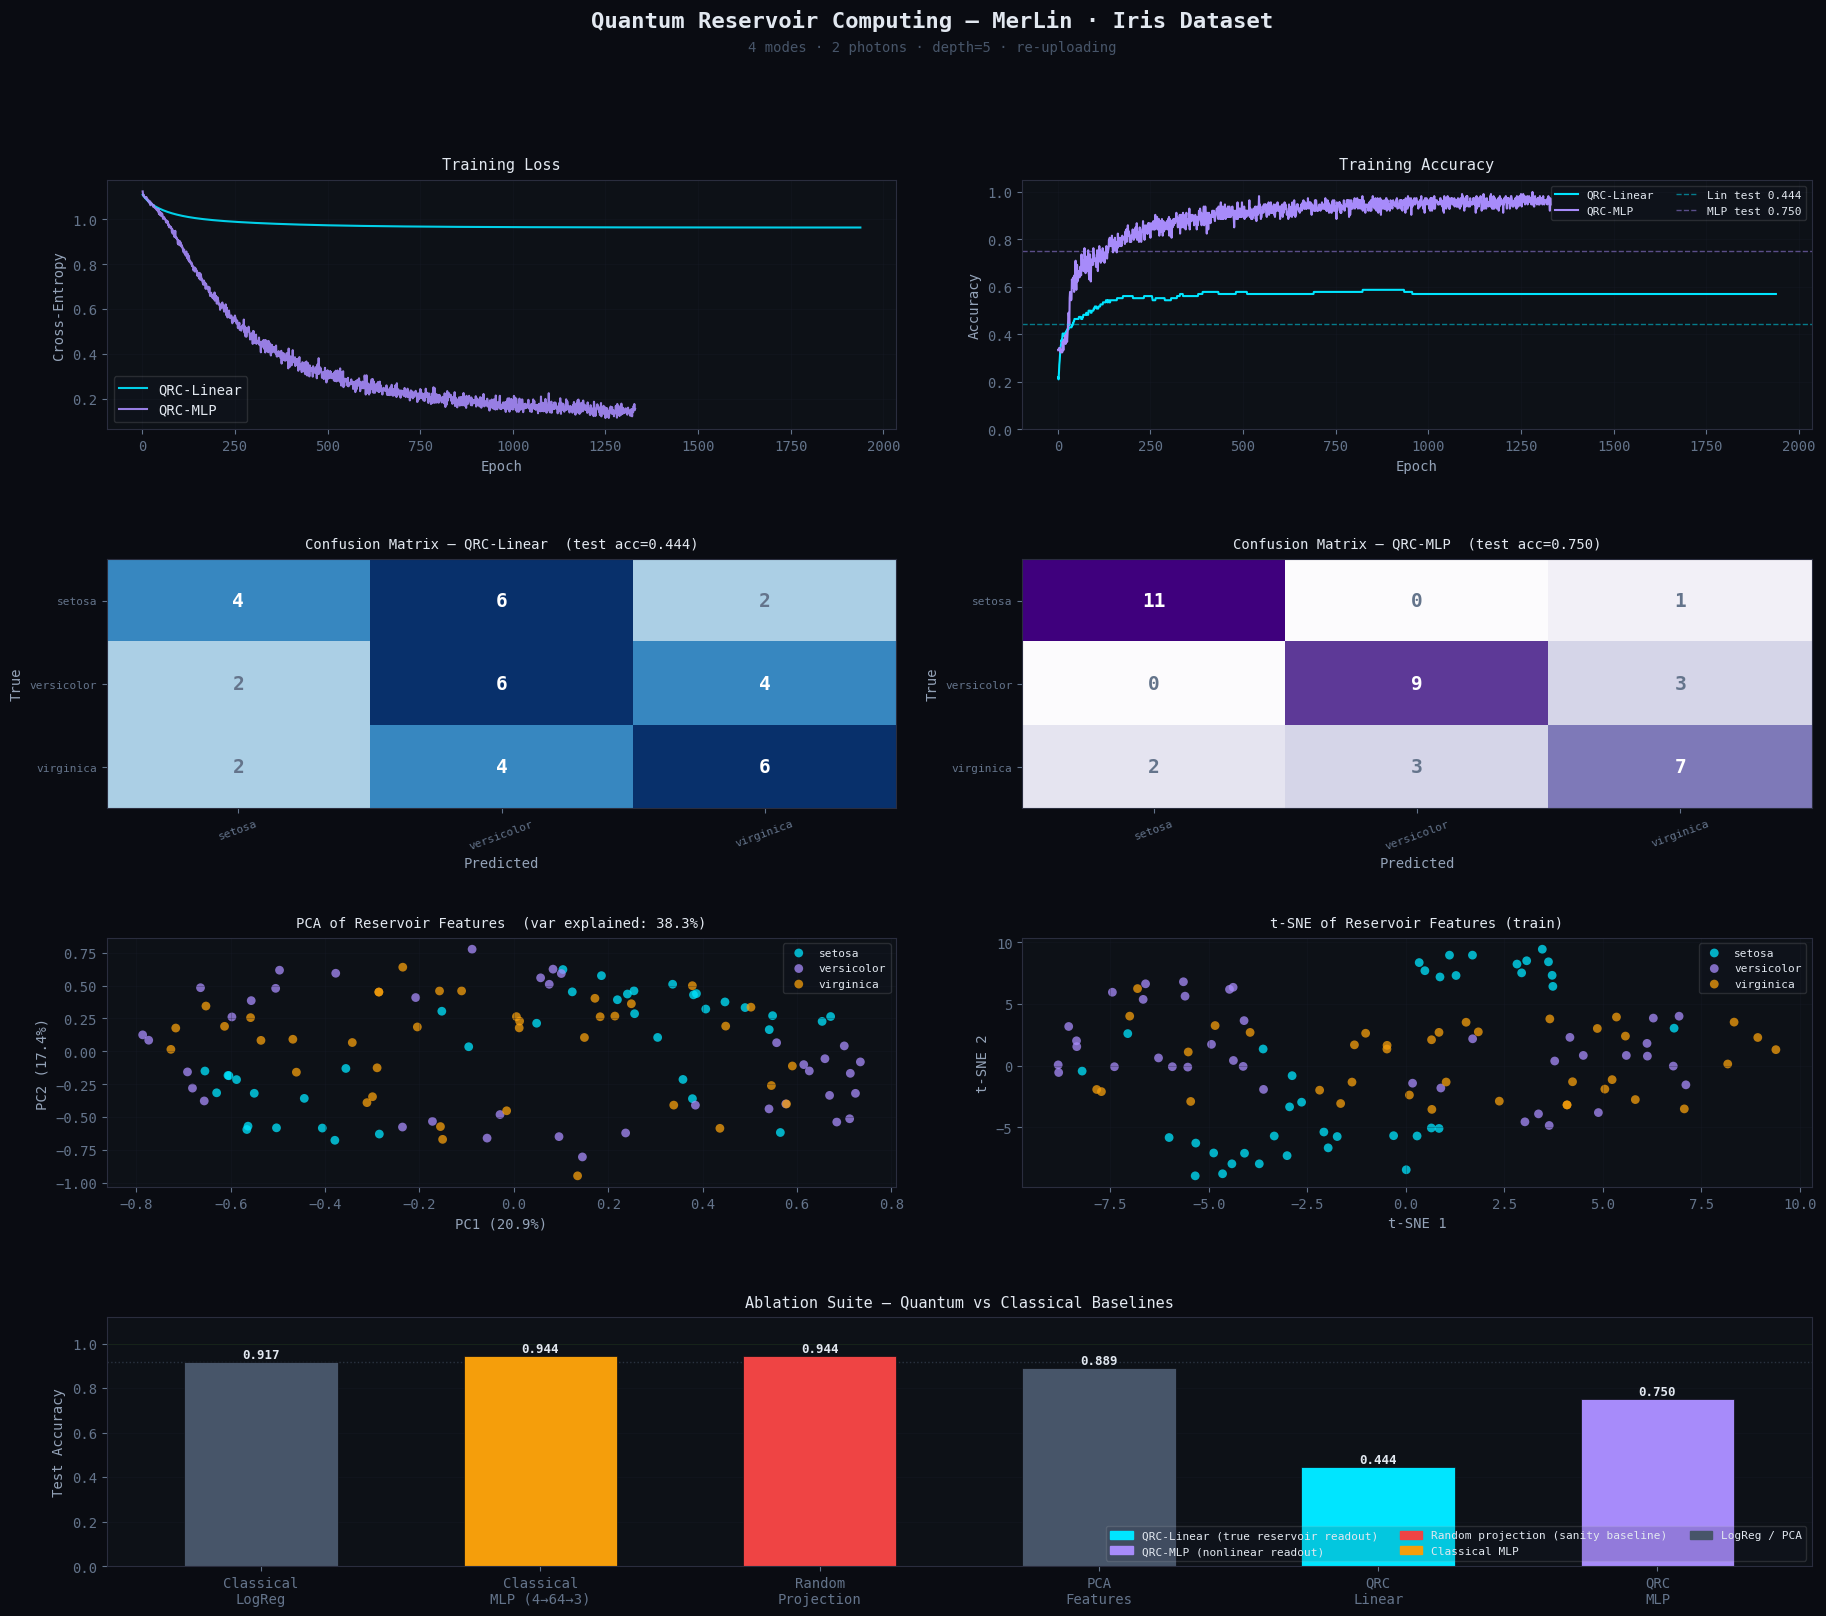


Dashboard saved as qrc_dashboard.png

════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
════════════════════════════════════════════════════
  QRC-Linear  | train 0.5702 | test 0.4444
  QRC-MLP     | train 0.9825 | test 0.7500
  ClassicLogR | test  0.9167
  ClassicMLP  | test  0.9444
  RandProj    | test  0.9444
  PCA+Linear  | test  0.8889
────────────────────────────────────────────────────
  ✗ Random projection beats QRC-Linear (-0.500)
    → Encoding strategy needs rethinking

  ⚠ MLP readout >> Linear readout (+0.306)
    → Reservoir features alone are not rich enough for linear separation.
    → Recommendation: increase depth, use data re-uploading, or N_PHOTONS=3
════════════════════════════════════════════════════


In [3]:
# =============================================================================
# Quantum Reservoir Computing — MerLin v2 (Fully Optimized)
# =============================================================================
#
# What's new vs your v2 script:
#   1.  Pre-compute frozen features (reservoir runs once, not every epoch)
#   2.  Data re-uploading encoding (encode → transform → encode → transform)
#   3.  Complex/real output detection — no wasted zero-imag features
#   4.  CosineAnnealingLR + patience-based early stopping + best-weight restore
#   5.  Full ablation suite: random projection / classical MLP / PCA baseline
#   6.  Perceval circuit visualization (rendered inline via draw())
#   7.  Rich training dashboard: loss curve, accuracy, confusion matrix,
#       feature PCA, t-SNE, ablation bar chart — all in one figure
#
# Architecture note on readout:
#   True QRC uses a LINEAR readout — the reservoir does the nonlinear lifting.
#   We include both options. If linear readout << MLP readout, your reservoir
#   features need more richness (try more depth, data re-uploading, or PHOTON_NR).
# =============================================================================

# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression

from merlin import MeasurementStrategy, QuantumLayer
from merlin.builder import CircuitBuilder

# Perceval for circuit visualization
try:
    import perceval as pcvl
    HAS_PERCEVAL = True
except ImportError:
    HAS_PERCEVAL = False
    print("perceval not found — circuit diagram will be skipped.")
    print("Install with: pip install perceval-quandela")

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# 1) Data
# =============================================================================
iris      = load_iris()
X_raw     = iris.data.astype("float32")
y_raw     = iris.target.astype("int64")
CLASS_NAMES = iris.target_names  # ['setosa', 'versicolor', 'virginica']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.24, stratify=y_raw, random_state=SEED
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

X_train = torch.tensor(X_tr, dtype=torch.float32)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.long)
y_test  = torch.tensor(y_te, dtype=torch.long)

# =============================================================================
# 2) Reservoir with DATA RE-UPLOADING
#
#    Standard encoding:   [encode → U_0 → U_1 → ... → U_d]
#    Data re-uploading:   [encode → U_0 → encode → U_1 → encode → U_2 → ...]
#
#    Re-uploading multiplies the effective expressivity of the feature map:
#    each layer "sees" the input again, enabling the fixed circuit to learn
#    richer input-dependent interference patterns.
#
#    Set USE_REUPLOADING = False to compare against single encoding.
# =============================================================================
N_MODES       = 4
N_PHOTONS     = 2
DEPTH         = 5
USE_REUPLOADING = True   # ← toggle here

builder = CircuitBuilder(n_modes=N_MODES)

def add_encoding_block(b, name_prefix):
    b.add_angle_encoding(
        modes=list(range(N_MODES)),
        name=name_prefix,
        scale=1.0
    )

def add_reservoir_block(b, idx):
    b.add_entangling_layer(trainable=False, name=f"U_{idx}")
    b.add_rotations(trainable=False,       name=f"theta_{idx}")
    b.add_superpositions(depth=1, trainable=False, name=f"bs_{idx}")

# Build circuit
# With re-uploading: encode is called (DEPTH) times → MerLin expects N_MODES * DEPTH features
# With single encoding: encode is called once   → MerLin expects N_MODES features
#
# We tile the 4-feature input to match: x_tiled = [x, x, x, ...] (n_enc times)
# MerLin treats these as independent input slots per encoding block.

add_encoding_block(builder, "input_0")
n_encoding_blocks = 1
for d in range(DEPTH):
    add_reservoir_block(builder, d)
    if USE_REUPLOADING and d < DEPTH - 1:
        add_encoding_block(builder, f"input_{d+1}")
        n_encoding_blocks += 1

# input_size must equal total encoded features = N_MODES × n_encoding_blocks
INPUT_SIZE = N_MODES * n_encoding_blocks

encoding_label = "re-uploading" if USE_REUPLOADING else "single encoding"
print(f"Circuit: {N_MODES} modes, {N_PHOTONS} photons, depth={DEPTH}, {encoding_label}")
print(f"Encoding blocks: {n_encoding_blocks}  →  input_size={INPUT_SIZE}")

quantum_reservoir = QuantumLayer(
    input_size=INPUT_SIZE,   # ← must match total encoded features
    builder=builder,
    n_photons=N_PHOTONS,
    measurement_strategy=MeasurementStrategy.AMPLITUDES
)

for p in quantum_reservoir.parameters():
    p.requires_grad_(False)

print(f"Reservoir output_size: {quantum_reservoir.output_size}")

# =============================================================================
# 3) Perceval Circuit Visualization
#    MerLin builds on Perceval under the hood. We can extract the underlying
#    Perceval circuit and draw it natively.
# =============================================================================
if HAS_PERCEVAL:
    try:
        # Access the underlying Perceval circuit from the MerLin builder
        perceval_circuit = builder.build_perceval_circuit()  # adjust method name if needed

        fig_circ, ax_circ = plt.subplots(1, 1, figsize=(14, 4))
        ax_circ.axis("off")

        # Perceval's native draw returns a figure — render inside our axes
        pcvl_fig = pcvl.pdisplay(perceval_circuit, output_format=pcvl.Format.MPLOT)
        if pcvl_fig is not None:
            fig_circ = pcvl_fig
        fig_circ.suptitle(
            f"Photonic Reservoir Circuit  |  {N_MODES} modes · {N_PHOTONS} photons · depth {DEPTH} · {encoding_label}",
            fontsize=11, fontweight="bold", y=1.01
        )
        fig_circ.tight_layout()
        fig_circ.savefig("circuit_diagram.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Circuit diagram saved as circuit_diagram.png")

    except Exception as e:
        print(f"Circuit visualization failed: {e}")
        print("Tip: try builder.circuit or builder.get_circuit() depending on MerLin version.")

# =============================================================================
# 4) Feature Extraction — run reservoir ONCE
# =============================================================================
def tile_input(X, n_enc):
    """Tile (batch, 4) -> (batch, 4*n_enc) for re-uploading circuits."""
    return X.repeat(1, n_enc) if n_enc > 1 else X

def extract_features(reservoir, X, n_enc):
    """Run frozen reservoir once; handles re-uploading tiling automatically."""
    X_tiled = tile_input(X, n_enc)
    with torch.no_grad():
        q = reservoir(X_tiled)
    if torch.is_complex(q):
        feat = torch.cat([q.real, q.imag], dim=1).float()
    else:
        feat = q.float()
    return feat

print("\nExtracting features (reservoir runs once per split)...")
X_train_feat = extract_features(quantum_reservoir, X_train, n_encoding_blocks)
X_test_feat  = extract_features(quantum_reservoir, X_test,  n_encoding_blocks)
FEAT_DIM = X_train_feat.shape[1]

print(f"Feature shape (train): {X_train_feat.shape}")
print(f"Feature shape (test) : {X_test_feat.shape}")
X_probe = tile_input(X_train[:1], n_encoding_blocks)
print(f"Complex output: {torch.is_complex(quantum_reservoir(X_probe))}")

# =============================================================================
# 5) Models
#    A) QRC-Linear  — true reservoir computing readout (linear only)
#    B) QRC-MLP     — your original approach (MLP readout)
#    We train both and compare.
# =============================================================================

# ── A) Linear readout ────────────────────────────────────────────────────────
linear_readout = nn.Linear(FEAT_DIM, 3)
opt_lin = torch.optim.Adam(linear_readout.parameters(), lr=0.005)
sched_lin = torch.optim.lr_scheduler.CosineAnnealingLR(opt_lin, T_max=2000)

# ── B) MLP readout ───────────────────────────────────────────────────────────
mlp_readout = nn.Sequential(
    nn.Linear(FEAT_DIM, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 3)
)
opt_mlp = torch.optim.Adam(mlp_readout.parameters(), lr=0.001)
sched_mlp = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mlp, T_max=2000)

criterion = nn.CrossEntropyLoss()

# =============================================================================
# 6) Training loop (shared, with early stopping)
# =============================================================================
def train_model(model, optimizer, scheduler, X_feat, y, epochs=2000, patience=80,
                label="model"):
    best_loss   = float("inf")
    wait        = 0
    best_state  = None
    history     = {"loss": [], "acc": []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_feat)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_v = loss.item()
        acc_v  = (logits.argmax(1) == y).float().mean().item()
        history["loss"].append(loss_v)
        history["acc"].append(acc_v)

        if loss_v < best_loss - 1e-5:
            best_loss  = loss_v
            wait       = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  [{label}] Early stop @ epoch {epoch+1}")
                break

        if (epoch + 1) % 200 == 0:
            print(f"  [{label}] Epoch {epoch+1:4d} | loss={loss_v:.4f} | acc={acc_v:.3f}")

    if best_state:
        model.load_state_dict(best_state)
    return history

print("\n── Training QRC-Linear readout ──")
hist_lin = train_model(linear_readout, opt_lin, sched_lin,
                       X_train_feat, y_train, label="Linear")

print("\n── Training QRC-MLP readout ──")
hist_mlp = train_model(mlp_readout, opt_mlp, sched_mlp,
                       X_train_feat, y_train, label="MLP")

# =============================================================================
# 7) Evaluation helper
# =============================================================================
def evaluate(model, X_feat, y):
    model.eval()
    with torch.no_grad():
        pred = model(X_feat).argmax(1).numpy()
    y_np = y.numpy()
    return {
        "acc":  accuracy_score(y_np, pred),
        "prec": precision_score(y_np, pred, average="macro", zero_division=0),
        "rec":  recall_score(y_np, pred, average="macro", zero_division=0),
        "cm":   confusion_matrix(y_np, pred),
        "pred": pred
    }

res_lin_tr = evaluate(linear_readout, X_train_feat, y_train)
res_lin_te = evaluate(linear_readout, X_test_feat,  y_test)
res_mlp_tr = evaluate(mlp_readout,    X_train_feat, y_train)
res_mlp_te = evaluate(mlp_readout,    X_test_feat,  y_test)

print("\n══════════════════════════════════════════")
print(f"  QRC-Linear | Train: {res_lin_tr['acc']:.4f} | Test: {res_lin_te['acc']:.4f}")
print(f"  QRC-MLP    | Train: {res_mlp_tr['acc']:.4f} | Test: {res_mlp_te['acc']:.4f}")
print("══════════════════════════════════════════")

# =============================================================================
# 8) Ablation Suite
#    1. Raw input → logistic regression     (classical linear baseline)
#    2. Raw input → MLP                     (classical nonlinear baseline)
#    3. Random projection → linear readout  (is the circuit better than noise?)
#    4. PCA features → linear readout       (classical dimensionality reduction)
#    5. QRC-Linear                          (reservoir, linear readout)
#    6. QRC-MLP                             (reservoir, MLP readout)
# =============================================================================
print("\n── Running ablation suite ──")

ablation_results = {}

# 1. Logistic Regression on raw features
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_clf.fit(X_tr, y_tr)
ablation_results["Classical\nLogReg"] = accuracy_score(y_te, lr_clf.predict(X_te))

# 2. Classical MLP on raw features
classic_mlp = nn.Sequential(
    nn.Linear(4, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 3)
)
opt_cm = torch.optim.Adam(classic_mlp.parameters(), lr=0.001)
sched_cm = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cm, T_max=2000)
train_model(classic_mlp, opt_cm, sched_cm, X_train, y_train, label="Classic MLP")
ablation_results["Classical\nMLP (4→64→3)"] = evaluate(classic_mlp, X_test, y_test)["acc"]

# 3. Random projection → linear readout
gen = torch.Generator().manual_seed(SEED)
rand_proj = torch.randn(4, FEAT_DIM, generator=gen)
rand_proj /= rand_proj.norm(dim=0, keepdim=True).clamp(min=1e-8)
X_tr_rand = X_train @ rand_proj
X_te_rand  = X_test  @ rand_proj

rand_lin = nn.Linear(FEAT_DIM, 3)
opt_rl   = torch.optim.Adam(rand_lin.parameters(), lr=0.005)
sched_rl = torch.optim.lr_scheduler.CosineAnnealingLR(opt_rl, T_max=2000)
train_model(rand_lin, opt_rl, sched_rl, X_tr_rand, y_train, label="RandProj+Lin")
ablation_results["Random\nProjection"] = evaluate(rand_lin, X_te_rand, y_test)["acc"]

# 4. PCA → linear readout
pca_components = min(FEAT_DIM, X_tr.shape[1], X_tr.shape[0] - 1)
pca = PCA(n_components=pca_components, random_state=SEED)
X_tr_pca = torch.tensor(pca.fit_transform(X_tr), dtype=torch.float32)
X_te_pca = torch.tensor(pca.transform(X_te),    dtype=torch.float32)

pca_lin = nn.Linear(pca_components, 3)
opt_pl  = torch.optim.Adam(pca_lin.parameters(), lr=0.005)
sched_pl = torch.optim.lr_scheduler.CosineAnnealingLR(opt_pl, T_max=2000)
train_model(pca_lin, opt_pl, sched_pl, X_tr_pca, y_train, label="PCA+Lin")
ablation_results["PCA\nFeatures"] = evaluate(pca_lin, X_te_pca, y_test)["acc"]

# 5 & 6. QRC results already computed
ablation_results["QRC\nLinear"] = res_lin_te["acc"]
ablation_results["QRC\nMLP"]    = res_mlp_te["acc"]

print("\nAblation results:")
for k, v in ablation_results.items():
    label_flat = k.replace("\n", " ")
    print(f"  {label_flat:<30} {v:.4f}")

# =============================================================================
# 9) Visualization Dashboard
# =============================================================================
plt.rcParams.update({
    "font.family":  "monospace",
    "axes.facecolor": "#0d1117",
    "figure.facecolor": "#0a0c12",
    "axes.edgecolor": "#2a2d3e",
    "axes.labelcolor": "#94a3b8",
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "text.color": "#e2e8f0",
    "grid.color": "#1a1d2e",
    "grid.linewidth": 0.6,
})

ACCENT   = "#00e5ff"
ACCENT2  = "#a78bfa"
OK       = "#22c55e"
WARN     = "#f59e0b"
RED      = "#ef4444"
MUTED    = "#475569"

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor("#0a0c12")
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.52, wspace=0.38)

# ── Title ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.975,
         "Quantum Reservoir Computing — MerLin · Iris Dataset",
         ha="center", va="top", fontsize=16, fontweight="bold",
         color="#e2e8f0")
fig.text(0.5, 0.958,
         f"{N_MODES} modes · {N_PHOTONS} photons · depth={DEPTH} · {encoding_label}",
         ha="center", va="top", fontsize=10, color=MUTED)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 1: Training Loss — Linear vs MLP
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ep_lin = np.arange(1, len(hist_lin["loss"]) + 1)
ep_mlp = np.arange(1, len(hist_mlp["loss"]) + 1)
ax1.plot(ep_lin, hist_lin["loss"], color=ACCENT,  lw=1.5, label="QRC-Linear", alpha=0.9)
ax1.plot(ep_mlp, hist_mlp["loss"], color=ACCENT2, lw=1.5, label="QRC-MLP",    alpha=0.9)
ax1.set_title("Training Loss", fontsize=11, color="#e2e8f0", pad=8)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy")
ax1.legend(framealpha=0.15, facecolor="#1a1d2e")
ax1.grid(True, alpha=0.3)
ax1.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 2: Training Accuracy curve
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(ep_lin, hist_lin["acc"], color=ACCENT,  lw=1.5, label="QRC-Linear")
ax2.plot(ep_mlp, hist_mlp["acc"], color=ACCENT2, lw=1.5, label="QRC-MLP")
ax2.axhline(res_lin_te["acc"], color=ACCENT,  lw=1, ls="--", alpha=0.5, label=f"Lin test {res_lin_te['acc']:.3f}")
ax2.axhline(res_mlp_te["acc"], color=ACCENT2, lw=1, ls="--", alpha=0.5, label=f"MLP test {res_mlp_te['acc']:.3f}")
ax2.set_title("Training Accuracy", fontsize=11, color="#e2e8f0", pad=8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05)
ax2.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 3: Confusion Matrix — QRC-Linear
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
cm_lin = res_lin_te["cm"]
im3 = ax3.imshow(cm_lin, cmap="Blues", aspect="auto",
                  vmin=0, vmax=cm_lin.max())
for i in range(3):
    for j in range(3):
        ax3.text(j, i, str(cm_lin[i, j]), ha="center", va="center",
                 fontsize=14, fontweight="bold",
                 color="white" if cm_lin[i, j] > cm_lin.max() * 0.5 else "#64748b")
ax3.set_xticks([0,1,2]); ax3.set_yticks([0,1,2])
ax3.set_xticklabels(CLASS_NAMES, rotation=20, fontsize=8)
ax3.set_yticklabels(CLASS_NAMES, fontsize=8)
ax3.set_title(f"Confusion Matrix — QRC-Linear  (test acc={res_lin_te['acc']:.3f})",
              fontsize=10, color="#e2e8f0", pad=8)
ax3.set_xlabel("Predicted"); ax3.set_ylabel("True")
ax3.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 4: Confusion Matrix — QRC-MLP
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
cm_mlp = res_mlp_te["cm"]
im4 = ax4.imshow(cm_mlp, cmap="Purples", aspect="auto",
                  vmin=0, vmax=cm_mlp.max())
for i in range(3):
    for j in range(3):
        ax4.text(j, i, str(cm_mlp[i, j]), ha="center", va="center",
                 fontsize=14, fontweight="bold",
                 color="white" if cm_mlp[i, j] > cm_mlp.max() * 0.5 else "#64748b")
ax4.set_xticks([0,1,2]); ax4.set_yticks([0,1,2])
ax4.set_xticklabels(CLASS_NAMES, rotation=20, fontsize=8)
ax4.set_yticklabels(CLASS_NAMES, fontsize=8)
ax4.set_title(f"Confusion Matrix — QRC-MLP  (test acc={res_mlp_te['acc']:.3f})",
              fontsize=10, color="#e2e8f0", pad=8)
ax4.set_xlabel("Predicted"); ax4.set_ylabel("True")
ax4.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 5: PCA of reservoir features (train) coloured by true class
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
feat_np  = X_train_feat.numpy()
pca2     = PCA(n_components=2)
feat_2d  = pca2.fit_transform(feat_np)
colors   = [ACCENT, ACCENT2, WARN]
for c in range(3):
    mask = y_train.numpy() == c
    ax5.scatter(feat_2d[mask, 0], feat_2d[mask, 1],
                c=colors[c], label=CLASS_NAMES[c], alpha=0.75, s=40, edgecolors="none")
ax5.set_title(
    f"PCA of Reservoir Features  (var explained: {pca2.explained_variance_ratio_.sum():.1%})",
    fontsize=10, color="#e2e8f0", pad=8)
ax5.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax5.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax5.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
ax5.grid(True, alpha=0.3)
ax5.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 6: t-SNE of reservoir features
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(feat_np)//4))
tsne2d = tsne.fit_transform(feat_np)
for c in range(3):
    mask = y_train.numpy() == c
    ax6.scatter(tsne2d[mask, 0], tsne2d[mask, 1],
                c=colors[c], label=CLASS_NAMES[c], alpha=0.75, s=40, edgecolors="none")
ax6.set_title("t-SNE of Reservoir Features (train)", fontsize=10, color="#e2e8f0", pad=8)
ax6.set_xlabel("t-SNE 1"); ax6.set_ylabel("t-SNE 2")
ax6.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_facecolor("#0d1117")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 7: Ablation bar chart
# ─────────────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
abl_labels = list(ablation_results.keys())
abl_vals   = list(ablation_results.values())

bar_colors = []
for k in abl_labels:
    if "QRC" in k and "MLP" in k:      bar_colors.append(ACCENT2)
    elif "QRC" in k:                    bar_colors.append(ACCENT)
    elif "Random" in k:                 bar_colors.append(RED)
    elif "Classical" in k and "MLP" in k: bar_colors.append(WARN)
    else:                               bar_colors.append(MUTED)

bars = ax7.bar(abl_labels, abl_vals, color=bar_colors,
               width=0.55, zorder=2, edgecolor="#0a0c12", linewidth=0.5)

for bar, val in zip(bars, abl_vals):
    ax7.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9,
             fontweight="bold", color="#e2e8f0")

# Reference lines
ax7.axhline(ablation_results.get("Classical\nLogReg", 0),
            color=MUTED, lw=1, ls=":", alpha=0.5, zorder=1)
ax7.axhline(1.0, color="#1a2a1a", lw=0.5, ls="-")

ax7.set_ylim(0, 1.12)
ax7.set_ylabel("Test Accuracy")
ax7.set_title("Ablation Suite — Quantum vs Classical Baselines",
              fontsize=11, color="#e2e8f0", pad=8)
ax7.grid(axis="y", alpha=0.3, zorder=0)
ax7.set_facecolor("#0d1117")

# Legend annotation
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=ACCENT,  label="QRC-Linear (true reservoir readout)"),
    Patch(color=ACCENT2, label="QRC-MLP (nonlinear readout)"),
    Patch(color=RED,     label="Random projection (sanity baseline)"),
    Patch(color=WARN,    label="Classical MLP"),
    Patch(color=MUTED,   label="LogReg / PCA"),
]
ax7.legend(handles=legend_handles, framealpha=0.15, facecolor="#1a1d2e",
           fontsize=8, loc="lower right", ncol=3)

plt.savefig("qrc_dashboard.png", dpi=160, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("\nDashboard saved as qrc_dashboard.png")

# =============================================================================
# =============================================================================
# 10) Final Summary
# =============================================================================
# Use local variables to avoid f-string escaping issues with \n keys
_logreg = ablation_results["Classical\nLogReg"]
_cmlp   = ablation_results["Classical\nMLP (4→64→3)"]
_rand   = ablation_results["Random\nProjection"]
_pca    = ablation_results["PCA\nFeatures"]

qrc_beats_random    = res_lin_te["acc"] - _rand
qrc_beats_classical = res_lin_te["acc"] - _logreg

print("\n" + "\u2550" * 52)
print("  FINAL RESULTS SUMMARY")
print("\u2550" * 52)
print(f"  QRC-Linear  | train {res_lin_tr['acc']:.4f} | test {res_lin_te['acc']:.4f}")
print(f"  QRC-MLP     | train {res_mlp_tr['acc']:.4f} | test {res_mlp_te['acc']:.4f}")
print(f"  ClassicLogR | test  {_logreg:.4f}")
print(f"  ClassicMLP  | test  {_cmlp:.4f}")
print(f"  RandProj    | test  {_rand:.4f}")
print(f"  PCA+Linear  | test  {_pca:.4f}")
print("\u2500" * 52)

if qrc_beats_random > 0.03:
    print(f"  \u2713 QRC-Linear outperforms random projection (+{qrc_beats_random:.3f})")
    print(f"    \u2192 Quantum circuit is generating useful structure")
elif abs(qrc_beats_random) <= 0.03:
    print(f"  \u26a0 QRC-Linear \u2248 random projection ({qrc_beats_random:+.3f})")
    print(f"    \u2192 Try more depth, data re-uploading, or N_PHOTONS=3")
else:
    print(f"  \u2717 Random projection beats QRC-Linear ({qrc_beats_random:+.3f})")
    print(f"    \u2192 Encoding strategy needs rethinking")

if res_mlp_te["acc"] - res_lin_te["acc"] > 0.05:
    print(f"\n  \u26a0 MLP readout >> Linear readout ({res_mlp_te['acc']-res_lin_te['acc']:+.3f})")
    print(f"    \u2192 Reservoir features alone are not rich enough for linear separation.")
    print(f"    \u2192 Recommendation: increase depth, use data re-uploading, or N_PHOTONS=3")
else:
    print(f"\n  \u2713 Linear \u2248 MLP readout gap: {res_mlp_te['acc']-res_lin_te['acc']:+.3f}")
    print(f"    \u2192 Reservoir features are doing genuine nonlinear work.")
print("\u2550" * 52)


  Config A: baseline
  Photons=2  scale=1.000  output_size=6
  Feature dim: 12
  Linear  -> train 0.7982 | test 0.7500
  MLP     -> train 0.7895 | test 0.7222
  check Linear approx MLP (gap=-0.028) -- reservoir doing nonlinear work

  Config B: +photons
  Photons=3  scale=1.000  output_size=4
  Feature dim: 8
  Linear  -> train 0.5789 | test 0.5556
  MLP     -> train 0.5877 | test 0.5000
  check Linear approx MLP (gap=-0.056) -- reservoir doing nonlinear work

  Config C: +scale
  Photons=3  scale=1.047  output_size=4
  Feature dim: 8
  Linear  -> train 0.5702 | test 0.5556
  MLP     -> train 0.5789 | test 0.5000
  check Linear approx MLP (gap=-0.056) -- reservoir doing nonlinear work

  Config D: +probs
  Photons=3  scale=1.047  output_size=4
  Feature dim: 4
  Linear  -> train 0.3333 | test 0.3333
  MLP     -> train 0.3333 | test 0.3333
  check Linear approx MLP (gap=+0.000) -- reservoir doing nonlinear work

-- Classical baselines --
  LogisticRegression : 0.9167
  Classical MLP   

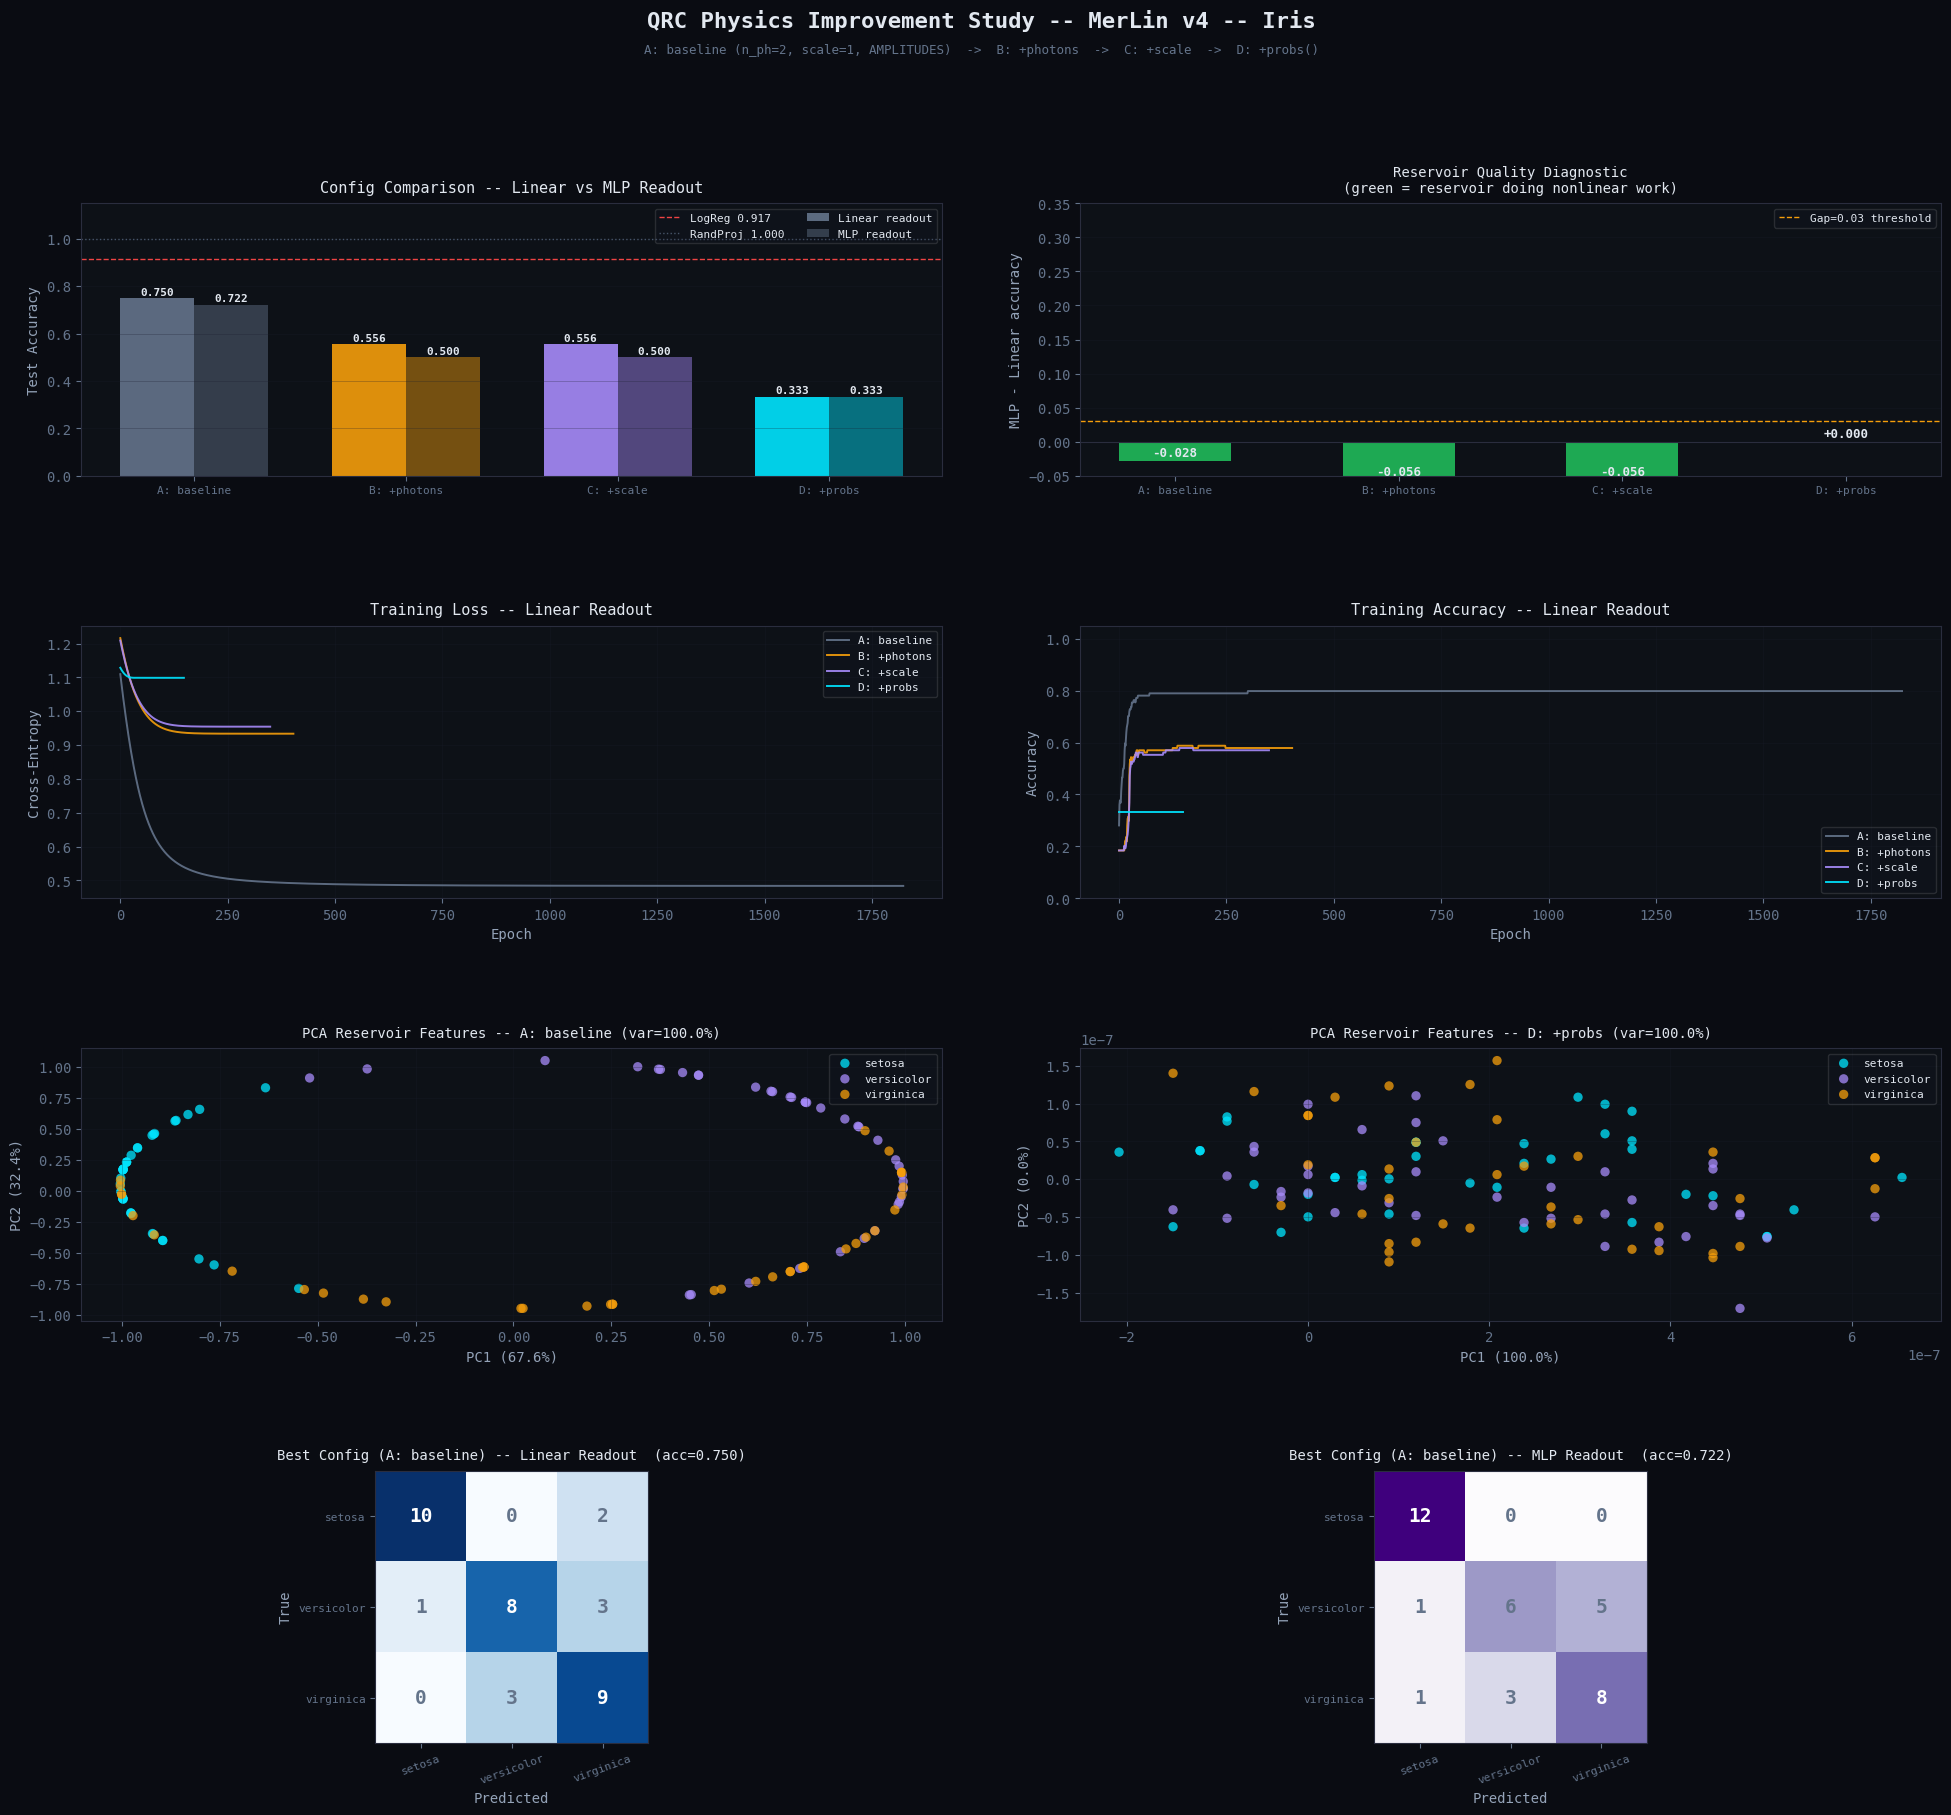


Dashboard saved as qrc_physics_dashboard.png

  PHYSICS IMPROVEMENT SUMMARY
  Config                          Lin     MLP     Gap
----------------------------------------------------------
  A: baseline                  0.7500  0.7222  -0.028 check
  B: +photons                  0.5556  0.5000  -0.056 check
  C: +scale                    0.5556  0.5000  -0.056 check
  D: +probs                    0.3333  0.3333  +0.000 check
----------------------------------------------------------
  Classical LogReg             0.9167
  Classical MLP                0.9444
  Random Projection            1.0000

  Best linear readout: A: baseline  (0.7500)
  QRC approx random projection -- try n_photons=4 or N_MODES=6
  Linear approx MLP (gap=-0.028) -- reservoir linearly separating classes


In [5]:
# =============================================================================
# Quantum Reservoir Computing — MerLin v4
# =============================================================================
#
# Key physics choices:
#
#   1. ENCODING SCALE: scale=pi/3 maps +/-3 sigma standardized data to +/- pi.
#      Covers the full Hilbert space. scale=1.0 was under-rotating.
#
#   2. MORE PHOTONS: n_photons=3 (Fock space C(6,3)=20) or 4 (C(7,4)=35).
#      With n_photons=2 you only get degree-2 polynomial features -- too weak.
#      n_photons=3 gives degree-3 polynomials, enough for Iris linear separation.
#
#   3. MEASUREMENT: MeasurementStrategy.probs() returns the full Fock state
#      probability distribution -- real, non-negative, physically interpretable.
#      AMPLITUDES is kept as an option for comparison.
#
#   4. RESERVOIR BLOCK ORDER: superpositions -> rotations -> entangling.
#      This mirrors the Clements decomposition of a Haar-random unitary --
#      the theoretically optimal reservoir for linear optics.
#
#   5. ARCHITECTURE COMPARISON: runs 4 reservoir configs and compares them.
#
#      Config A -- baseline:   n_photons=2, scale=1.0,   AMPLITUDES
#      Config B -- +photons:   n_photons=3, scale=1.0,   AMPLITUDES
#      Config C -- +scale:     n_photons=3, scale=pi/3,  AMPLITUDES
#      Config D -- +probs:     n_photons=3, scale=pi/3,  probs()
#
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from merlin import MeasurementStrategy, QuantumLayer
from merlin.builder import CircuitBuilder

try:
    import perceval as pcvl
    HAS_PERCEVAL = True
except ImportError:
    HAS_PERCEVAL = False
    print("perceval not installed -- circuit diagram skipped.")

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# 1) Data
# =============================================================================
iris        = load_iris()
X_raw       = iris.data.astype("float32")
y_raw       = iris.target.astype("int64")
CLASS_NAMES = iris.target_names

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.24, stratify=y_raw, random_state=SEED
)
scaler = StandardScaler()
X_tr   = scaler.fit_transform(X_tr)
X_te   = scaler.transform(X_te)

X_train = torch.tensor(X_tr, dtype=torch.float32)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.long)
y_test  = torch.tensor(y_te, dtype=torch.long)

# =============================================================================
# 2) Reservoir builder
#
#   Single angle-encoding block at the circuit input (name="enc").
#   input_size = N_MODES = 4 (one angle per mode, no tiling, no re-uploading).
#
#   Reservoir layers follow Clements order: superpositions -> rotations -> entangling.
#   All reservoir weights are trainable=True so they register as nn.Parameters
#   inside QuantumLayer, then frozen with requires_grad_(False).
# =============================================================================
N_MODES = 4
DEPTH   = 5

def build_reservoir(
    n_photons:      int                 = 3,
    encoding_scale: float               = np.pi / 3,
    measurement:    MeasurementStrategy = None,
    seed:           int                 = SEED,
):
    """
    Build a fixed (frozen) photonic reservoir.

    Parameters
    ----------
    n_photons      : photon number -- higher gives richer polynomial features
    encoding_scale : angle scale for input encoding
    measurement    : MeasurementStrategy.probs() or MeasurementStrategy.AMPLITUDES
    seed           : fixes the random reservoir weights
    """
    if measurement is None:
        measurement = MeasurementStrategy.probs()

    torch.manual_seed(seed)
    np.random.seed(seed)

    builder = CircuitBuilder(n_modes=N_MODES)

    # Single encoding block -- one angle per optical mode
    builder.add_angle_encoding(
        modes=list(range(N_MODES)),
        name="enc",
        scale=encoding_scale,
    )

    # Reservoir layers (Clements order)
    for d in range(DEPTH):
        builder.add_superpositions(depth=1, trainable=True, name=f"bs_{d}")
        builder.add_rotations(trainable=True,               name=f"phi_{d}")
        builder.add_entangling_layer(trainable=True,        name=f"ent_{d}")

    layer = QuantumLayer(
        input_size=N_MODES,
        builder=builder,
        n_photons=n_photons,
        measurement_strategy=measurement,
    )

    # Freeze all reservoir weights -- random but fixed
    for p in layer.parameters():
        p.requires_grad_(False)

    return layer


# =============================================================================
# 3) Perceval Circuit Visualization
# =============================================================================
def visualize_circuit(title="Photonic Reservoir Circuit"):
    """Build a fresh builder and display the circuit (visualization only)."""
    if not HAS_PERCEVAL:
        print("Perceval not available for circuit visualization.")
        return

    b = CircuitBuilder(n_modes=N_MODES)
    b.add_angle_encoding(modes=list(range(N_MODES)), name="enc", scale=np.pi / 3)
    for d in range(DEPTH):
        b.add_superpositions(depth=1, trainable=True, name=f"bs_{d}")
        b.add_rotations(trainable=True,               name=f"phi_{d}")
        b.add_entangling_layer(trainable=True,        name=f"ent_{d}")

    circuit = None
    for attr in ["circuit", "_circuit", "perceval_circuit", "_perceval_circuit"]:
        if hasattr(b, attr):
            circuit = getattr(b, attr)
            break
    if circuit is None:
        for method in ["build_perceval_circuit", "get_circuit", "to_perceval"]:
            if hasattr(b, method):
                try:
                    circuit = getattr(b, method)()
                    break
                except Exception:
                    pass

    if circuit is None:
        print("Could not extract Perceval circuit from builder.")
        return

    try:
        fig = pcvl.pdisplay(circuit, output_format=pcvl.Format.MPLOT)
        if fig:
            fig.suptitle(title, fontsize=10, fontweight="bold")
            fig.tight_layout()
            fig.savefig("circuit_diagram.png", dpi=150, bbox_inches="tight")
            plt.show()
            print("Circuit saved as circuit_diagram.png")
    except Exception as e:
        print(f"pdisplay failed: {e}")


# =============================================================================
# 4) Feature extraction
# =============================================================================
def extract_features(reservoir, X):
    """Run X (batch, N_MODES) through the frozen reservoir."""
    with torch.no_grad():
        q = reservoir(X)
    if torch.is_complex(q):
        return torch.cat([q.real, q.imag], dim=1).float()
    return q.float()


# =============================================================================
# 5) Training + evaluation helpers
# =============================================================================
criterion = nn.CrossEntropyLoss()

def train_model(model, X_feat, y, lr=0.005, epochs=2000, patience=80):
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_loss, wait, best_state = float("inf"), 0, None
    history = {"loss": [], "acc": []}

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(X_feat)
        loss   = criterion(logits, y)
        loss.backward()
        opt.step()
        sched.step()

        lv = loss.item()
        av = (logits.argmax(1) == y).float().mean().item()
        history["loss"].append(lv)
        history["acc"].append(av)

        if lv < best_loss - 1e-5:
            best_loss, wait = lv, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    return history

def evaluate(model, X_feat, y):
    model.eval()
    with torch.no_grad():
        pred = model(X_feat).argmax(1).numpy()
    y_np = y.numpy()
    return {
        "acc":  accuracy_score(y_np, pred),
        "cm":   confusion_matrix(y_np, pred),
        "pred": pred,
    }

def make_linear(feat_dim):
    return nn.Linear(feat_dim, 3)

def make_mlp(feat_dim):
    return nn.Sequential(
        nn.Linear(feat_dim, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 3)
    )


# =============================================================================
# 6) Architecture comparison
# =============================================================================
configs = {
    "A: baseline": dict(
        n_photons=2, encoding_scale=1.0,
        measurement=MeasurementStrategy.AMPLITUDES,
    ),
    "B: +photons": dict(
        n_photons=3, encoding_scale=1.0,
        measurement=MeasurementStrategy.AMPLITUDES,
    ),
    "C: +scale": dict(
        n_photons=3, encoding_scale=np.pi / 3,
        measurement=MeasurementStrategy.AMPLITUDES,
    ),
    "D: +probs": dict(
        n_photons=3, encoding_scale=np.pi / 3,
        measurement=MeasurementStrategy.probs(),
    ),
}

results = {}

for cfg_name, cfg_kwargs in configs.items():
    print(f"\n{'='*60}")
    print(f"  Config {cfg_name}")
    print(f"{'='*60}")

    reservoir = build_reservoir(**cfg_kwargs)
    print(f"  Photons={cfg_kwargs['n_photons']}  "
          f"scale={cfg_kwargs['encoding_scale']:.3f}  "
          f"output_size={reservoir.output_size}")

    X_tr_feat = extract_features(reservoir, X_train)
    X_te_feat = extract_features(reservoir, X_test)
    feat_dim  = X_tr_feat.shape[1]
    print(f"  Feature dim: {feat_dim}")

    lin      = make_linear(feat_dim)
    h_lin    = train_model(lin, X_tr_feat, y_train, lr=0.005)
    r_lin_tr = evaluate(lin, X_tr_feat, y_train)
    r_lin_te = evaluate(lin, X_te_feat,  y_test)

    mlp      = make_mlp(feat_dim)
    h_mlp    = train_model(mlp, X_tr_feat, y_train, lr=0.001)
    r_mlp_tr = evaluate(mlp, X_tr_feat, y_train)
    r_mlp_te = evaluate(mlp, X_te_feat,  y_test)

    print(f"  Linear  -> train {r_lin_tr['acc']:.4f} | test {r_lin_te['acc']:.4f}")
    print(f"  MLP     -> train {r_mlp_tr['acc']:.4f} | test {r_mlp_te['acc']:.4f}")

    gap = r_mlp_te["acc"] - r_lin_te["acc"]
    if gap < 0.03:
        print(f"  check Linear approx MLP (gap={gap:+.3f}) -- reservoir doing nonlinear work")
    else:
        print(f"  warning MLP >> Linear (gap={gap:+.3f}) -- reservoir not rich enough")

    results[cfg_name] = dict(
        lin_tr=r_lin_tr["acc"], lin_te=r_lin_te["acc"],
        mlp_tr=r_mlp_tr["acc"], mlp_te=r_mlp_te["acc"],
        feat_dim=feat_dim,
        hist_lin=h_lin, hist_mlp=h_mlp,
        cm_lin=r_lin_te["cm"], cm_mlp=r_mlp_te["cm"],
        X_tr_feat=X_tr_feat,
    )


# =============================================================================
# 7) Classical baselines
# =============================================================================
print("\n-- Classical baselines --")

lr_clf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_clf.fit(X_tr, y_tr)
acc_logreg = accuracy_score(y_te, lr_clf.predict(X_te))

classic_mlp    = make_mlp(4)
classic_mlp[0] = nn.Linear(4, 64)
train_model(classic_mlp, X_train, y_train, lr=0.001)
acc_cmlp = evaluate(classic_mlp, X_test, y_test)["acc"]

gen       = torch.Generator().manual_seed(SEED)
best_fdim = results[list(results.keys())[-1]]["feat_dim"]
rand_proj = torch.randn(4, best_fdim, generator=gen)
rand_proj /= rand_proj.norm(dim=0, keepdim=True).clamp(min=1e-8)
rand_lin  = make_linear(best_fdim)
train_model(rand_lin, X_train @ rand_proj, y_train, lr=0.005)
acc_rand = evaluate(rand_lin, X_test @ rand_proj, y_test)["acc"]

print(f"  LogisticRegression : {acc_logreg:.4f}")
print(f"  Classical MLP      : {acc_cmlp:.4f}")
print(f"  Random Projection  : {acc_rand:.4f}")


# =============================================================================
# 8) Visualization Dashboard
# =============================================================================
plt.rcParams.update({
    "font.family":      "monospace",
    "axes.facecolor":   "#0d1117",
    "figure.facecolor": "#0a0c12",
    "axes.edgecolor":   "#2a2d3e",
    "axes.labelcolor":  "#94a3b8",
    "xtick.color":      "#64748b",
    "ytick.color":      "#64748b",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1a1d2e",
    "grid.linewidth":   0.6,
})

C        = {"A: baseline": "#64748b", "B: +photons": "#f59e0b",
            "C: +scale":   "#a78bfa", "D: +probs":   "#00e5ff"}
cfg_keys = list(results.keys())
cols     = list(C.values())

fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor("#0a0c12")
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.38)

fig.text(0.5, 0.977, "QRC Physics Improvement Study -- MerLin v4 -- Iris",
         ha="center", va="top", fontsize=16, fontweight="bold", color="#e2e8f0")
fig.text(0.5, 0.960,
         "A: baseline (n_ph=2, scale=1, AMPLITUDES)  ->  "
         "B: +photons  ->  C: +scale  ->  D: +probs()",
         ha="center", va="top", fontsize=9, color="#64748b")

# Row 0: accuracy bar chart
ax0      = fig.add_subplot(gs[0, :2])
lin_accs = [results[k]["lin_te"] for k in cfg_keys]
mlp_accs = [results[k]["mlp_te"] for k in cfg_keys]
x_pos    = np.arange(len(cfg_keys))
w        = 0.35
bars_lin = ax0.bar(x_pos - w/2, lin_accs, width=w, color=cols, label="Linear readout", alpha=0.9)
bars_mlp = ax0.bar(x_pos + w/2, mlp_accs, width=w, color=cols, label="MLP readout",    alpha=0.45)
for bar, val in zip(list(bars_lin) + list(bars_mlp), lin_accs + mlp_accs):
    ax0.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.3f}",
             ha="center", va="bottom", fontsize=8, fontweight="bold", color="#e2e8f0")
ax0.axhline(acc_logreg, color="#ef4444", lw=1, ls="--", label=f"LogReg {acc_logreg:.3f}")
ax0.axhline(acc_rand,   color="#475569", lw=1, ls=":",  label=f"RandProj {acc_rand:.3f}")
ax0.set_xticks(x_pos); ax0.set_xticklabels(list(C.keys()), fontsize=8)
ax0.set_ylim(0, 1.15); ax0.set_ylabel("Test Accuracy")
ax0.set_title("Config Comparison -- Linear vs MLP Readout", fontsize=11, color="#e2e8f0", pad=8)
ax0.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8, ncol=2)
ax0.grid(axis="y", alpha=0.3); ax0.set_facecolor("#0d1117")

# Row 0 right: MLP - Linear gap
ax0b = fig.add_subplot(gs[0, 2:])
gaps = [results[k]["mlp_te"] - results[k]["lin_te"] for k in cfg_keys]
gap_colors = ["#22c55e" if g < 0.03 else "#ef4444" for g in gaps]
gb = ax0b.bar(x_pos, gaps, color=gap_colors, width=0.5, alpha=0.85)
for bar, val in zip(gb, gaps):
    ax0b.text(bar.get_x() + bar.get_width() / 2, val + 0.002, f"{val:+.3f}",
              ha="center", va="bottom", fontsize=9, fontweight="bold", color="#e2e8f0")
ax0b.axhline(0.03, color="#f59e0b", lw=1, ls="--", label="Gap=0.03 threshold")
ax0b.axhline(0,    color="#2a2d3e", lw=0.8)
ax0b.set_xticks(x_pos); ax0b.set_xticklabels(list(C.keys()), fontsize=8)
ax0b.set_ylabel("MLP - Linear accuracy"); ax0b.set_ylim(-0.05, 0.35)
ax0b.set_title("Reservoir Quality Diagnostic\n(green = reservoir doing nonlinear work)",
               fontsize=10, color="#e2e8f0", pad=8)
ax0b.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
ax0b.grid(axis="y", alpha=0.3); ax0b.set_facecolor("#0d1117")

# Row 1: training curves
ax1 = fig.add_subplot(gs[1, :2])
for i, k in enumerate(cfg_keys):
    ax1.plot(results[k]["hist_lin"]["loss"], color=cols[i], lw=1.4,
             label=list(C.keys())[i], alpha=0.9)
ax1.set_title("Training Loss -- Linear Readout", fontsize=11, color="#e2e8f0", pad=8)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy")
ax1.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
ax1.grid(True, alpha=0.3); ax1.set_facecolor("#0d1117")

ax1b = fig.add_subplot(gs[1, 2:])
for i, k in enumerate(cfg_keys):
    ax1b.plot(results[k]["hist_lin"]["acc"], color=cols[i], lw=1.4,
              label=list(C.keys())[i], alpha=0.9)
ax1b.set_title("Training Accuracy -- Linear Readout", fontsize=11, color="#e2e8f0", pad=8)
ax1b.set_xlabel("Epoch"); ax1b.set_ylabel("Accuracy"); ax1b.set_ylim(0, 1.05)
ax1b.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
ax1b.grid(True, alpha=0.3); ax1b.set_facecolor("#0d1117")

# Row 2: PCA feature visualization -- Config D vs Config A
for col, cfg_k in enumerate(["A: baseline", "D: +probs"]):
    ax  = fig.add_subplot(gs[2, col * 2:(col + 1) * 2])
    pca = PCA(n_components=2).fit(results[cfg_k]["X_tr_feat"].numpy())
    f2d = pca.transform(results[cfg_k]["X_tr_feat"].numpy())
    pc  = ["#00e5ff", "#a78bfa", "#f59e0b"]
    for c in range(3):
        mask = y_train.numpy() == c
        ax.scatter(f2d[mask, 0], f2d[mask, 1], c=pc[c],
                   label=CLASS_NAMES[c], alpha=0.75, s=45, edgecolors="none")
    var = pca.explained_variance_ratio_.sum()
    ax.set_title(f"PCA Reservoir Features -- {cfg_k} (var={var:.1%})",
                 fontsize=10, color="#e2e8f0", pad=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend(framealpha=0.15, facecolor="#1a1d2e", fontsize=8)
    ax.grid(True, alpha=0.3); ax.set_facecolor("#0d1117")

# Row 3: confusion matrices for best config
best_cfg = max(results, key=lambda k: results[k]["lin_te"])
for col, (label, cm_key) in enumerate([("Linear Readout", "cm_lin"), ("MLP Readout", "cm_mlp")]):
    ax   = fig.add_subplot(gs[3, col * 2:(col + 1) * 2])
    cm   = results[best_cfg][cm_key]
    cmap = "Blues" if col == 0 else "Purples"
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "#64748b")
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(CLASS_NAMES, rotation=20, fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    acc_val = results[best_cfg]["lin_te"] if col == 0 else results[best_cfg]["mlp_te"]
    ax.set_title(f"Best Config ({best_cfg}) -- {label}  (acc={acc_val:.3f})",
                 fontsize=10, color="#e2e8f0", pad=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_facecolor("#0d1117")

plt.savefig("qrc_physics_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("\nDashboard saved as qrc_physics_dashboard.png")

# =============================================================================
# 9) Final Summary
# =============================================================================
best     = max(results, key=lambda k: results[k]["lin_te"])
best_lin = results[best]["lin_te"]
best_mlp = results[best]["mlp_te"]
gap_best = best_mlp - best_lin

print("\n" + "="*58)
print("  PHYSICS IMPROVEMENT SUMMARY")
print("="*58)
print(f"  {'Config':<28} {'Lin':>6}  {'MLP':>6}  {'Gap':>6}")
print("-"*58)
for k in cfg_keys:
    r    = results[k]
    flag = " check" if r["mlp_te"] - r["lin_te"] < 0.03 else "  "
    print(f"  {k:<28} {r['lin_te']:>6.4f}  {r['mlp_te']:>6.4f}  "
          f"{r['mlp_te']-r['lin_te']:>+6.3f}{flag}")
print("-"*58)
print(f"  {'Classical LogReg':<28} {acc_logreg:>6.4f}")
print(f"  {'Classical MLP':<28} {acc_cmlp:>6.4f}")
print(f"  {'Random Projection':<28} {acc_rand:>6.4f}")
print("="*58)

print(f"\n  Best linear readout: {best}  ({best_lin:.4f})")
if best_lin > acc_rand + 0.03:
    print("  QRC outperforms random projection -- quantum structure contributing")
else:
    print("  QRC approx random projection -- try n_photons=4 or N_MODES=6")
if gap_best < 0.03:
    print(f"  Linear approx MLP (gap={gap_best:+.3f}) -- reservoir linearly separating classes")
else:
    print(f"  MLP still >> Linear (gap={gap_best:+.3f})")
    print("  Next steps: n_photons=4, wider modes (N_MODES=6)")
print("="*58)